<a href="https://colab.research.google.com/github/ljpetkovic/Charcot_circulations/blob/main/dataviz/Courbe_nb_termes_TF_IDF_BM25_PatternRank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Charcot -- graphique global des courbes avec nb termes vs. scores

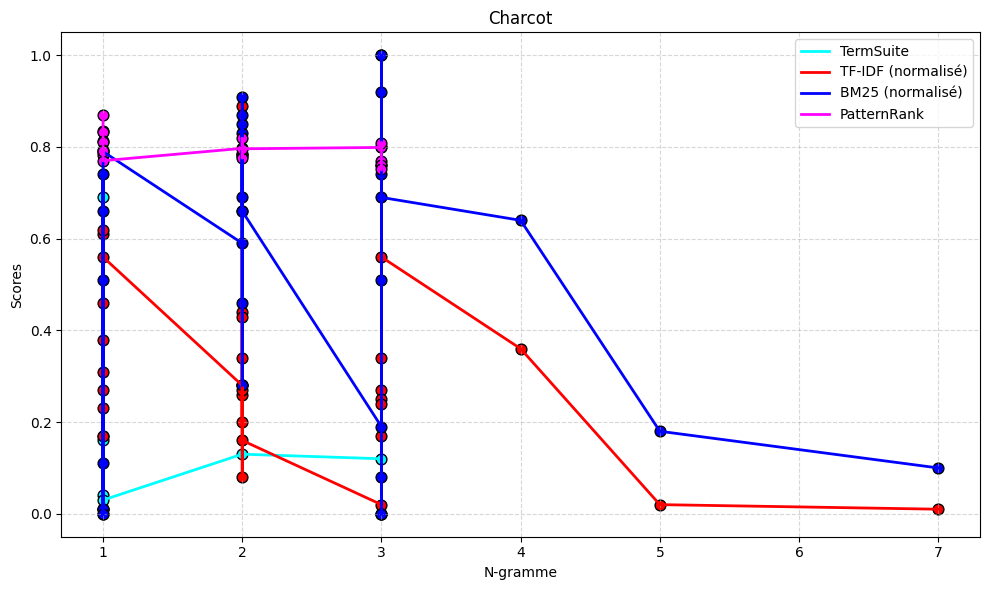

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# Load CSV
# ======================
df = pd.read_csv("courbe_termes_scores_charcot.csv")

# ======================
# Scores à tracer (couleur + label de légende)
# ======================
score_columns = {
    "TermSuite": {
        "color": "cyan",
        "label": "TermSuite"
    },
    "Normalized_TF-IDF": {
        "color": "red",
        "label": "TF-IDF (normalisé)"
    },
    "Normalized_BM25": {
        "color": "blue",
        "label": "BM25 (normalisé)"
    },
    "PatternRank": {
        "color": "magenta",
        "label": "PatternRank"
    }
}

# ======================
# Type conversion
# ======================
df["N-gramme"] = pd.to_numeric(df["N-gramme"], errors="coerce")

for col in score_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ======================
# Plot
# ======================
plt.figure(figsize=(10, 6))

for col, params in score_columns.items():
    color = params["color"]
    label = params["label"]

    # Exclure les NA uniquement pour ce score
    df_clean = df.dropna(subset=["N-gramme", col])

    # Trier par Nb_termes (abscisse)
    df_sorted = df_clean.sort_values("N-gramme")

    # Line
    plt.plot(
        df_sorted["N-gramme"],
        df_sorted[col],
        label=label,
        linewidth=2,
        color=color
    )

    # Points
    plt.scatter(
        df_sorted["N-gramme"],
        df_sorted[col],
        color=color,
        edgecolor="black",
        s=60
    )

# ======================
# Formatting
# ======================
plt.xlabel("N-gramme")
plt.ylabel("Scores")
plt.title("Charcot")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("courbe_scores_vs_nb_termes_charcot.png", dpi=600)
plt.show()


# Autres -- graphique global des courbes avec nb termes vs. scores

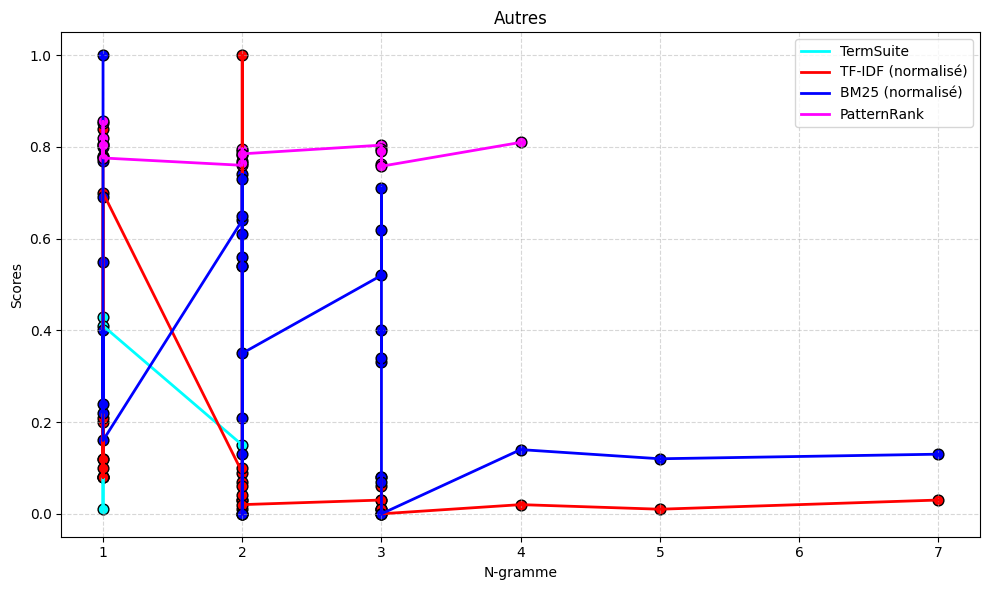

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# Load CSV
# ======================
df = pd.read_csv("courbe_termes_scores_autres.csv")

# ======================
# Scores à tracer (couleur + label de légende)
# ======================
score_columns = {
    "TermSuite": {
        "color": "cyan",
        "label": "TermSuite"
    },
    "Normalized_TF-IDF": {
        "color": "red",
        "label": "TF-IDF (normalisé)"
    },
    "Normalized_BM25": {
        "color": "blue",
        "label": "BM25 (normalisé)"
    },
    "PatternRank": {
        "color": "magenta",
        "label": "PatternRank"
    }
}

# ======================
# Type conversion
# ======================
df["N-gramme"] = pd.to_numeric(df["N-gramme"], errors="coerce")

for col in score_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ======================
# Plot
# ======================
plt.figure(figsize=(10, 6))

for col, params in score_columns.items():
    color = params["color"]
    label = params["label"]

    # Exclure les NA uniquement pour ce score
    df_clean = df.dropna(subset=["N-gramme", col])

    # Trier par Nb_termes (abscisse)
    df_sorted = df_clean.sort_values("N-gramme")

    # Line
    plt.plot(
        df_sorted["N-gramme"],
        df_sorted[col],
        label=label,
        linewidth=2,
        color=color
    )

    # Points
    plt.scatter(
        df_sorted["N-gramme"],
        df_sorted[col],
        color=color,
        edgecolor="black",
        s=60
    )

# ======================
# Formatting
# ======================
plt.xlabel("N-gramme")
plt.ylabel("Scores")
plt.title("Autres")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("courbe_scores_vs_nb_termes_autres.png", dpi=600)
plt.show()


# Charcot -- graphiques individuels (points)

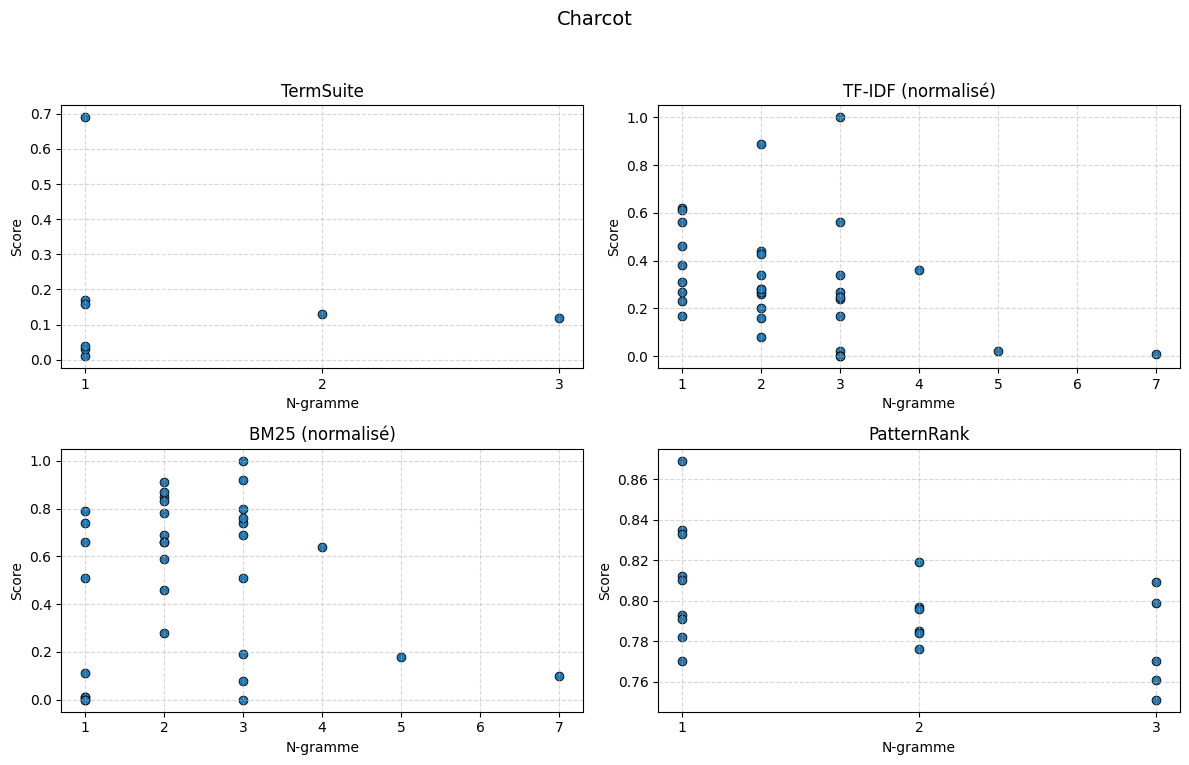

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- Load CSV ---
csv_path = "courbe_termes_scores_charcot.csv"
df = pd.read_csv(csv_path)

# --- Columns ---
x_col = "N-gramme"
score_cols = ["TermSuite", "Normalized_TF-IDF", "Normalized_BM25", "PatternRank"]

# --- Display labels (for plotting only) ---
display_labels = {
    "TermSuite": "TermSuite",
    "Normalized_TF-IDF": "TF-IDF (normalisé)",
    "Normalized_BM25": "BM25 (normalisé)",
    "PatternRank": "PatternRank"
}

# --- Convert to numeric ---
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
for c in score_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows where N-gramme is NA
df = df.dropna(subset=[x_col])

def plot_subplots_points(df, score_cols, title, out_png=None):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, score_cols):
        d = df[[x_col, col]].dropna()

        ax.scatter(
            d[x_col],
            d[col],
            s=40,
            edgecolor="black",
            linewidth=0.6
        )

        ax.set_title(display_labels[col])
        ax.set_xlabel("N-gramme")
        ax.set_ylabel("Score")
        ax.grid(True, linestyle="--", alpha=0.5)

        # N-gramme is discrete
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Hide unused axes if any
    for i in range(len(score_cols), len(axes)):
        axes[i].axis("off")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if out_png:
        fig.savefig(out_png, dpi=600)

    return fig

plot_subplots_points(
    df,
    score_cols,
    title="Charcot",
    out_png="courbes_scores_subplots_points_charcot.png",
)

plt.show()


# Autres -- graphiques individuels (points)

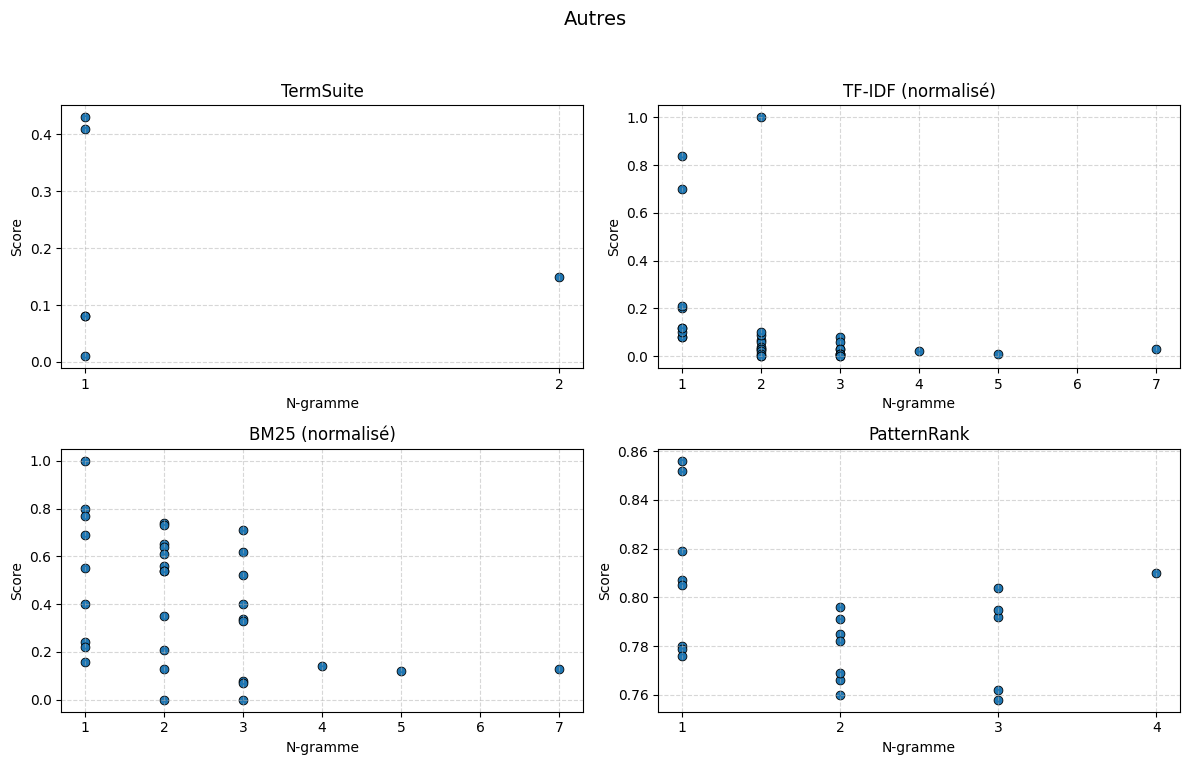

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- Load CSV ---
csv_path = "courbe_termes_scores_autres.csv"
df = pd.read_csv(csv_path)

# --- Columns ---
x_col = "N-gramme"
score_cols = ["TermSuite", "Normalized_TF-IDF", "Normalized_BM25", "PatternRank"]

# --- Display labels (for plotting only) ---
display_labels = {
    "TermSuite": "TermSuite",
    "Normalized_TF-IDF": "TF-IDF (normalisé)",
    "Normalized_BM25": "BM25 (normalisé)",
    "PatternRank": "PatternRank"
}

# --- Convert to numeric ---
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
for c in score_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows where N-gramme is NA
df = df.dropna(subset=[x_col])

def plot_subplots_points(df, score_cols, title, out_png=None):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, score_cols):
        d = df[[x_col, col]].dropna()

        ax.scatter(
            d[x_col],
            d[col],
            s=40,
            edgecolor="black",
            linewidth=0.6
        )

        ax.set_title(display_labels[col])
        ax.set_xlabel("N-gramme")
        ax.set_ylabel("Score")
        ax.grid(True, linestyle="--", alpha=0.5)

        # N-gramme is discrete
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Hide unused axes if any
    for i in range(len(score_cols), len(axes)):
        axes[i].axis("off")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if out_png:
        fig.savefig(out_png, dpi=600)

    return fig

plot_subplots_points(
    df,
    score_cols,
    title="Autres",
    out_png="courbes_scores_subplots_points_autres.png",
)

plt.show()


# Ligne médiane + aire (Charcot + Autres)

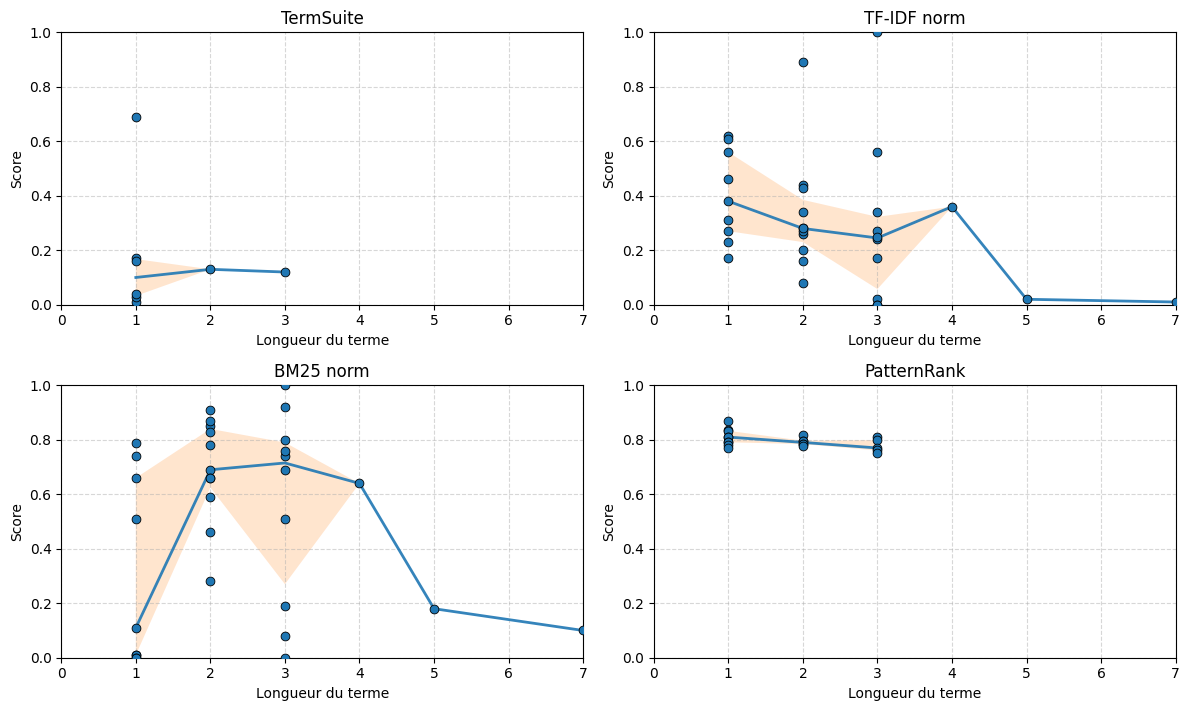

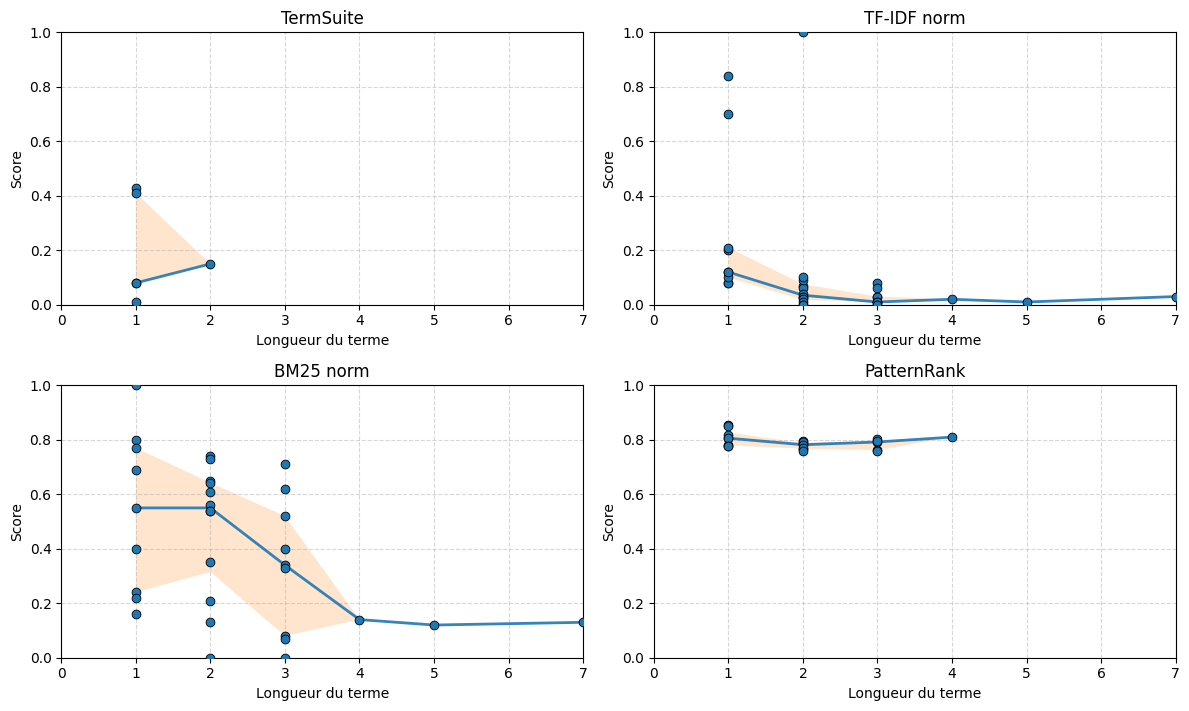

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- Columns ---
x_col = "N-gramme"
score_cols = ["TermSuite", "TF-IDF_norm", "BM25_norm", "PatternRank"]

# --- Display labels (for plotting only) ---
display_labels = {
    "TermSuite": "TermSuite",
    "TF-IDF_norm": "TF-IDF norm",
    "BM25_norm": "BM25 norm",
    "PatternRank": "PatternRank"
}

def plot_subplots_points_and_summary(df, score_cols, title, out_png=None):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, score_cols):
        d = df[[x_col, col]].dropna()

        # Points (observations)
        ax.scatter(
            d[x_col], d[col],
            s=40, edgecolor="black", linewidth=0.6, zorder=3
        )

        # Agrégation par N-gramme
        g = d.groupby(x_col)[col]
        summary = pd.DataFrame({
            "median": g.median(),
            "q25": g.quantile(0.25),
            "q75": g.quantile(0.75),
        }).reset_index().sort_values(x_col)

        # Ligne = médiane
        ax.plot(summary[x_col], summary["median"], linewidth=2, alpha=0.9)

        # Bande = IQR
        ax.fill_between(summary[x_col], summary["q25"], summary["q75"], alpha=0.2)

        ax.set_title(display_labels[col])
        ax.set_xlabel("Longueur du terme")
        ax.set_ylabel("Score")
        ax.grid(True, linestyle="--", alpha=0.5)

        # Échelle commune à tous les sous-graphiques
        ax.set_xlim(0, 7)
        ax.set_ylim(0, 1)

        # ticks entiers 0..7
        ax.set_xticks(range(0, 8))
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    for i in range(len(score_cols), len(axes)):
        axes[i].axis("off")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if out_png:
        fig.savefig(out_png, dpi=600)

    return fig


for tag in ["charcot", "autres"]:
    csv_path = f"courbe_termes_scores_{tag}.csv"
    df = pd.read_csv(csv_path)

    # --- Convert to numeric ---
    df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    for c in score_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Drop rows where N-gramme is NA
    df = df.dropna(subset=[x_col])

    plot_subplots_points_and_summary(
        df,
        score_cols,
        title="",
        out_png=f"courbes_scores_subplots_points_lines_aires_{tag}.png",
    )

plt.show()


# Charcot : ligne médiane + aire

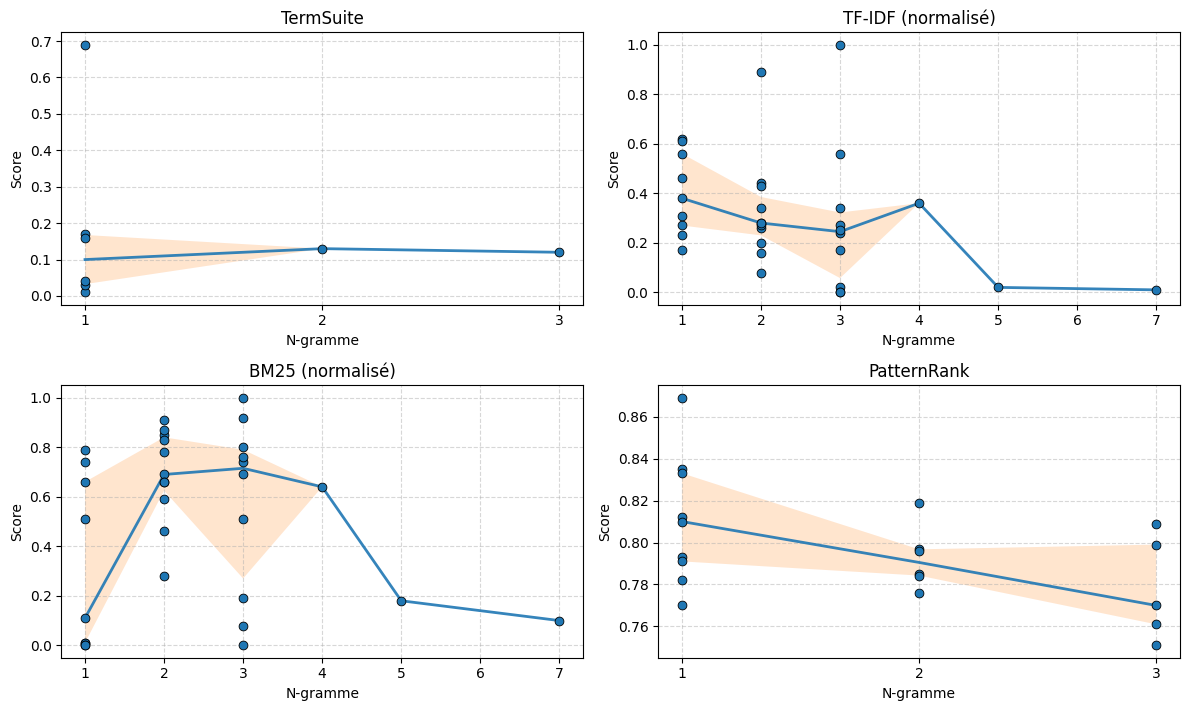

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- Load CSV ---
csv_path = "courbe_termes_scores_charcot.csv"
df = pd.read_csv(csv_path)

# --- Columns ---
x_col = "N-gramme"
score_cols = ["TermSuite", "Normalized_TF-IDF", "Normalized_BM25", "PatternRank"]

# --- Display labels (for plotting only) ---
display_labels = {
    "TermSuite": "TermSuite",
    "Normalized_TF-IDF": "TF-IDF (normalisé)",
    "Normalized_BM25": "BM25 (normalisé)",
    "PatternRank": "PatternRank"
}

# --- Convert to numeric ---
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
for c in score_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows where N-gramme is NA
df = df.dropna(subset=[x_col])

def plot_subplots_points_and_summary(df, score_cols, title, out_png=None):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, score_cols):
        d = df[[x_col, col]].dropna()

        # Points (observations)
        ax.scatter(
            d[x_col], d[col],
            s=40, edgecolor="black", linewidth=0.6, zorder=3
        )

        # Agrégation par N-gramme
        g = d.groupby(x_col)[col]
        summary = pd.DataFrame({
            "median": g.median(),
            "q25": g.quantile(0.25),
            "q75": g.quantile(0.75),
        }).reset_index().sort_values(x_col)

        # Ligne = médiane
        ax.plot(summary[x_col], summary["median"], linewidth=2, alpha=0.9)

        # Bande = IQR
        ax.fill_between(summary[x_col], summary["q25"], summary["q75"], alpha=0.2)

        ax.set_title(display_labels[col])
        ax.set_xlabel("N-gramme")
        ax.set_ylabel("Score")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    for i in range(len(score_cols), len(axes)):
        axes[i].axis("off")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if out_png:
        fig.savefig(out_png, dpi=600)

    return fig


plot_subplots_points_and_summary(
    df,
    score_cols,
    title="",
    out_png="courbes_scores_subplots_points_lines_charcot.png",
)

plt.show()

# Autres : ligne médiane + aire

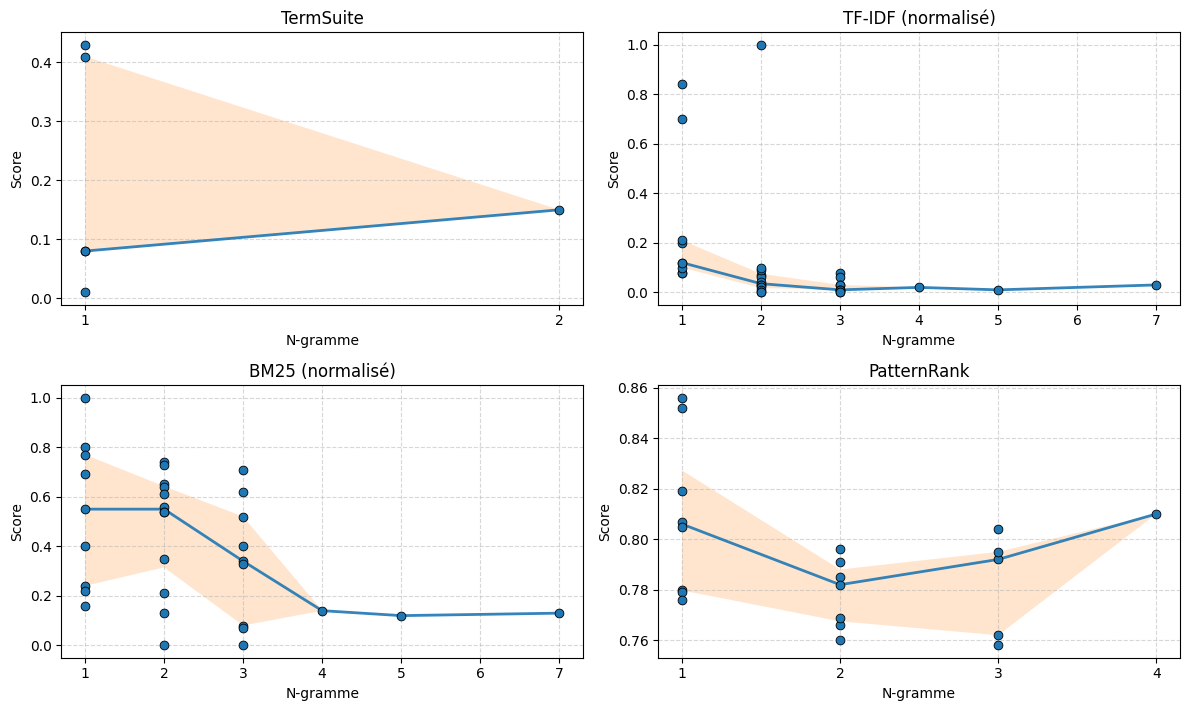

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- Load CSV ---
csv_path = "courbe_termes_scores_autres.csv"
df = pd.read_csv(csv_path)

# --- Columns ---
x_col = "N-gramme"
score_cols = ["TermSuite", "Normalized_TF-IDF", "Normalized_BM25", "PatternRank"]

# --- Display labels (for plotting only) ---
display_labels = {
    "TermSuite": "TermSuite",
    "Normalized_TF-IDF": "TF-IDF (normalisé)",
    "Normalized_BM25": "BM25 (normalisé)",
    "PatternRank": "PatternRank"
}

# --- Convert to numeric ---
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
for c in score_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows where N-gramme is NA
df = df.dropna(subset=[x_col])

def plot_subplots_points_and_summary(df, score_cols, title, out_png=None):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, score_cols):
        d = df[[x_col, col]].dropna()

        # Points (observations)
        ax.scatter(
            d[x_col], d[col],
            s=40, edgecolor="black", linewidth=0.6, zorder=3
        )

        # Agrégation par N-gramme
        g = d.groupby(x_col)[col]
        summary = pd.DataFrame({
            "median": g.median(),
            "q25": g.quantile(0.25),
            "q75": g.quantile(0.75),
        }).reset_index().sort_values(x_col)

        # Ligne = médiane
        ax.plot(summary[x_col], summary["median"], linewidth=2, alpha=0.9)

        # Bande = IQR
        ax.fill_between(summary[x_col], summary["q25"], summary["q75"], alpha=0.2)

        ax.set_title(display_labels[col])
        ax.set_xlabel("N-gramme")
        ax.set_ylabel("Score")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    for i in range(len(score_cols), len(axes)):
        axes[i].axis("off")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if out_png:
        fig.savefig(out_png, dpi=600)

    return fig


plot_subplots_points_and_summary(
    df,
    score_cols,
    title="",
    out_png="courbes_scores_subplots_points_lines_autres.png",
)

plt.show()

# UpSet Plots

In [ ]:
!pip -q install upsetplot

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from upsetplot import UpSet, from_indicators


# =========================
# CONFIG
# =========================
FILES = {
    "Charcot": "courbe_termes_scores_charcot.csv",
    "Autres":  "courbe_termes_scores_autres.csv",
}

MEASURES = ["TermSuite", "Normalized_TF-IDF", "Normalized_BM25", "PatternRank"]
TOP = 0.10  # top 10%

# colonne qui identifie les "termes" (unité d'analyse)
TERM_COL = "Regex"

# Comment agréger si un terme apparaît plusieurs fois :
# - "max" : un terme est valorisé si AU MOINS une occurrence a un score élevé
# - "mean": score moyen (plus conservateur)
AGG = "max"


# =========================
# HELPERS
# =========================
def build_term_scores(df: pd.DataFrame, term_col: str, measures=MEASURES, agg=AGG) -> pd.DataFrame:
    """
    Retourne un tableau [n_termes_uniques x n_mesures] avec 1 ligne par terme (agrégé).
    """
    if term_col not in df.columns:
        raise ValueError(f"Colonne TERM_COL='{term_col}' introuvable. Colonnes: {list(df.columns)}")

    df = df.copy()
    df[term_col] = df[term_col].astype(str)

    for m in measures:
        if m not in df.columns:
            raise ValueError(f"Colonne mesure '{m}' introuvable. Colonnes: {list(df.columns)}")
        df[m] = pd.to_numeric(df[m], errors="coerce")

    # Agrégation 1 ligne par terme
    if agg == "max":
        g = df.groupby(term_col)[measures].max()
    elif agg == "mean":
        g = df.groupby(term_col)[measures].mean()
    else:
        raise ValueError("AGG must be 'max' or 'mean'")

    return g


def make_indicators_topk(term_scores: pd.DataFrame, top=TOP) -> pd.DataFrame:
    """
    Construit le DataFrame booléen ind[terme, mesure] = True si le terme est dans le TOP-k
    de la mesure. TOP-k exact (= ceil(top * N_non_nan)).
    """
    ind = pd.DataFrame(False, index=term_scores.index, columns=term_scores.columns)

    for m in term_scores.columns:
        s = term_scores[m].dropna()
        if len(s) == 0:
            continue
        k = int(math.ceil(top * len(s)))
        top_terms = s.sort_values(ascending=False).head(k).index
        ind.loc[top_terms, m] = True

    return ind


def plot_upset(ind: pd.DataFrame, title: str, out_png: str):
    data = from_indicators(ind.columns.tolist(), ind.reset_index(drop=True))

    fig = plt.figure(figsize=(10, 6))
    axes = UpSet(
        data,
        show_counts=True,
        show_percentages=True,
        sort_by="degree",
    ).plot(fig=fig)

    axes["intersections"].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes["totals"].xaxis.set_major_locator(MaxNLocator(integer=True))

    # améliorer lisibilité
    for text in axes["totals"].texts:
        text.set_fontsize(9)
        text.set_alpha(0.85)

    for text in axes["intersections"].texts:
        text.set_fontsize(8)

    # enlever parenthèses autour des %
    for t in axes["intersections"].texts:
        txt = t.get_text()
        if "%" in txt:
            t.set_text(txt.replace("(", "").replace(")", ""))

    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()


def list_terms_valued_by_multiple_measures(ind: pd.DataFrame, min_measures: int = 2):
    """
    Retourne:
    - terms_min: termes valorisés par >= min_measures
    - by_degree: dict {k: [termes]} pour k mesures (k=2,3,4)
    - by_combo: dict {tuple(bool...): [termes]} pour combinaisons exactes
    """
    cols = ind.columns.tolist()
    degree = ind.sum(axis=1).astype(int)

    terms_min = ind.index[degree >= min_measures].tolist()

    by_degree = {k: ind.index[degree == k].tolist() for k in range(1, len(cols) + 1)}

    by_combo = {}
    for term, row in ind.iterrows():
        key = tuple(bool(row[c]) for c in cols)
        by_combo.setdefault(key, []).append(term)

    return terms_min, by_degree, by_combo, cols


def combo_label(cols, key):
    on = [c for c, v in zip(cols, key) if v]
    return " ∩ ".join(on) if on else "(none)"


# =========================
# MAIN
# =========================
def main():
    for corpus, path in FILES.items():
        df = pd.read_csv(path)

        # 1) 1 ligne par TERME (agrégé), scores numériques
        term_scores = build_term_scores(df, term_col=TERM_COL, measures=MEASURES, agg=AGG)

        # 2) indicateurs booléens TOP-k exact (top 10%)
        ind = make_indicators_topk(term_scores, top=TOP)

        # 3) plot
        out_png = f"upset_{corpus.lower()}_top{int(TOP*100)}_{TERM_COL.lower()}_{AGG}.png"
        plot_upset(ind, f"UpSet — {corpus} (top {int(TOP*100)}%, unité={TERM_COL}, agg={AGG})", out_png)

        # 4) listes: termes valorisés par plusieurs mesures
        terms_min, by_degree, by_combo, cols = list_terms_valued_by_multiple_measures(ind, min_measures=2)

        print("\n" + "="*70)
        print(f"[{corpus}] Unité={TERM_COL} | agg={AGG} | top={int(TOP*100)}% (TOP-k exact)")
        print(f"Nb termes uniques: {len(ind)}")
        print(f"Termes valorisés par >=2 mesures: {len(terms_min)}")

        # Par degré (2,3,4 mesures)
        for k in range(2, len(cols)+1):
            lst = by_degree.get(k, [])
            print(f"\n--- {k} mesure(s) --- ({len(lst)})")
            for t in lst:
                print("  -", t)

        # (Optionnel) détail par combinaison exacte
        print("\nDétail par combinaison exacte (≥2 mesures) :")
        for key, terms in sorted(by_combo.items(), key=lambda kv: (-sum(kv[0]), -len(kv[1]))):
            if sum(key) < 2:
                continue
            print(f"- {combo_label(cols, key)} : {len(terms)}")
            for t in terms:
                print("   •", t)

        print(f"\nPNG: {out_png}")

    print("\nOK.")

if __name__ == "__main__":
    main()


/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,


[Charcot] Unité=Regex | agg=max | top=10% (TOP-k exact)
Nb termes uniques: 33
Termes valorisés par >=2 mesures: 2

--- 2 mesure(s) --- (1)
  - Ataxie(s)? locomotrice(s)? progressive(s)?

--- 3 mesure(s) --- (1)
  - Hystérie(s)?

--- 4 mesure(s) --- (0)

Détail par combinaison exacte (≥2 mesures) :
- TermSuite ∩ Normalized_TF-IDF ∩ PatternRank : 1
   • Hystérie(s)?
- Normalized_TF-IDF ∩ Normalized_BM25 : 1
   • Ataxie(s)? locomotrice(s)? progressive(s)?

PNG: upset_charcot_top10_regex_max.png


/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,


[Autres] Unité=Regex | agg=max | top=10% (TOP-k exact)
Nb termes uniques: 33
Termes valorisés par >=2 mesures: 4

--- 2 mesure(s) --- (3)
  - Athétose(s)?
  - Hystérie(s)?
  - [EÉ]pilepsie(s)?

--- 3 mesure(s) --- (1)
  - Hypnose(s)?

--- 4 mesure(s) --- (0)

Détail par combinaison exacte (≥2 mesures) :
- TermSuite ∩ Normalized_TF-IDF ∩ Normalized_BM25 : 1
   • Hypnose(s)?
- Normalized_TF-IDF ∩ PatternRank : 2
   • Hystérie(s)?
   • [EÉ]pilepsie(s)?
- Normalized_BM25 ∩ PatternRank : 1
   • Athétose(s)?

PNG: upset_autres_top10_regex_max.png

OK.


In [ ]:
# --- Install (Colab) ---
!pip -q install upsetplot

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from upsetplot import UpSet, from_indicators


# =========================
# CONFIG
# =========================
FILES = {
    "Charcot": "courbe_termes_scores_charcot.csv",
    "Autres":  "courbe_termes_scores_autres.csv",
}

MEASURES = ["TermSuite", "TF-IDF_norm", "BM25_norm", "PatternRank"]
TOP = 0.10  # top 10%

# colonne qui identifie les "termes" (unité d'analyse)
TERM_COL = "Regex"

# Comment agréger si un terme apparaît plusieurs fois :
# - "max" : un terme est valorisé si AU MOINS une occurrence a un score élevé
# - "mean": score moyen (plus conservateur)
AGG = "max"


# =========================
# HELPERS
# =========================
def build_term_scores(df: pd.DataFrame, term_col: str, measures=MEASURES, agg=AGG) -> pd.DataFrame:
    """
    Retourne un tableau [n_termes_uniques x n_mesures] avec 1 ligne par terme (agrégé).
    """
    if term_col not in df.columns:
        raise ValueError(f"Colonne TERM_COL='{term_col}' introuvable. Colonnes: {list(df.columns)}")

    df = df.copy()
    df[term_col] = df[term_col].astype(str)

    for m in measures:
        if m not in df.columns:
            raise ValueError(f"Colonne mesure '{m}' introuvable. Colonnes: {list(df.columns)}")
        df[m] = pd.to_numeric(df[m], errors="coerce")

    # Agrégation 1 ligne par terme
    if agg == "max":
        g = df.groupby(term_col)[measures].max()
    elif agg == "mean":
        g = df.groupby(term_col)[measures].mean()
    else:
        raise ValueError("AGG must be 'max' or 'mean'")

    return g


def make_indicators_topk(term_scores: pd.DataFrame, top=TOP) -> pd.DataFrame:
    """
    Construit le DataFrame booléen ind[terme, mesure] = True si le terme est dans le TOP-k
    de la mesure. TOP-k exact (= ceil(top * N_non_nan)).
    """
    ind = pd.DataFrame(False, index=term_scores.index, columns=term_scores.columns)

    for m in term_scores.columns:
        s = term_scores[m].dropna()
        if len(s) == 0:
            continue
        k = int(math.ceil(top * len(s)))
        top_terms = s.sort_values(ascending=False).head(k).index
        ind.loc[top_terms, m] = True

    return ind


def plot_upset(ind: pd.DataFrame, title: str, out_png: str):
    data = from_indicators(ind.columns.tolist(), ind.reset_index(drop=True))

    fig = plt.figure(figsize=(10, 6))
    axes = UpSet(
        data,
        show_counts=True,
        show_percentages=True,
        sort_by="degree",
    ).plot(fig=fig)

    axes["intersections"].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes["totals"].xaxis.set_major_locator(MaxNLocator(integer=True))

    # améliorer lisibilité
    for text in axes["totals"].texts:
        text.set_fontsize(9)
        text.set_alpha(0.85)

    for text in axes["intersections"].texts:
        text.set_fontsize(8)

    # enlever parenthèses autour des %
    for t in axes["intersections"].texts:
        txt = t.get_text()
        if "%" in txt:
            t.set_text(txt.replace("(", "").replace(")", ""))

    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()


def list_terms_valued_by_multiple_measures(ind: pd.DataFrame, min_measures: int = 2):
    """
    Retourne:
    - terms_min: termes valorisés par >= min_measures
    - by_degree: dict {k: [termes]} pour k mesures (k=2,3,4)
    - by_combo: dict {tuple(bool...): [termes]} pour combinaisons exactes
    """
    cols = ind.columns.tolist()
    degree = ind.sum(axis=1).astype(int)

    terms_min = ind.index[degree >= min_measures].tolist()

    by_degree = {k: ind.index[degree == k].tolist() for k in range(1, len(cols) + 1)}

    by_combo = {}
    for term, row in ind.iterrows():
        key = tuple(bool(row[c]) for c in cols)
        by_combo.setdefault(key, []).append(term)

    return terms_min, by_degree, by_combo, cols


def combo_label(cols, key):
    on = [c for c, v in zip(cols, key) if v]
    return " ∩ ".join(on) if on else "(none)"


# ---------- vérification + exports ----------
def verify_by_combo(ind: pd.DataFrame, by_combo: dict):
    """
    Vérifie que by_combo est cohérent avec ind (anti-erreur),
    et affiche un listing lisible des combinaisons non vides.
    """
    cols = ind.columns.tolist()

    # 1) Vérif somme = nb lignes
    total_terms = sum(len(v) for v in by_combo.values())
    assert total_terms == len(ind), f"Incohérence: somme by_combo={total_terms} != len(ind)={len(ind)}"

    # 2) Vérif chaque terme est dans la bonne combinaison
    for key, terms in by_combo.items():
        for t in terms:
            row = ind.loc[t, cols].tolist()
            row_key = tuple(bool(x) for x in row)
            assert row_key == key, f"Terme '{t}' mal classé: {row_key} != {key}"

    # 3) Affichage
    print("\n=== Vérification détaillée des combinaisons (non vides) ===")
    for key, terms in sorted(by_combo.items(), key=lambda kv: (-sum(kv[0]), -len(kv[1]))):
        active = [c for c, v in zip(cols, key) if v]
        label = " ∩ ".join(active) if active else "(aucune mesure)"
        print(f"- {label} : {len(terms)}")
        for t in terms:
            print("  •", t)


def export_lists(ind: pd.DataFrame, by_degree: dict, by_combo: dict, corpus: str, term_col: str, agg: str, top: float):
    """
    Exporte:
    - CSV + LaTeX des combinaisons exactes (by_combo)
    - CSV + LaTeX des degrés (by_degree)
    """
    cols = ind.columns.tolist()
    top_pct = int(round(top * 100))

    # --- Combinaisons exactes ---
    rows = []
    for key, terms in by_combo.items():
        active = [c for c, v in zip(cols, key) if v]
        rows.append({
            "corpus": corpus,
            "active_measures": " ∩ ".join(active) if active else "(none)",
            "degree": int(sum(key)),
            "n_terms": int(len(terms)),
            "terms": " ; ".join(terms),
        })
    df_combo = pd.DataFrame(rows).sort_values(by=["degree", "n_terms"], ascending=[False, False])

    csv_combo = f"upset_lists_{corpus.lower()}_top{top_pct}_{term_col.lower()}_{agg}_by_combo.csv"
    tex_combo = f"upset_lists_{corpus.lower()}_top{top_pct}_{term_col.lower()}_{agg}_by_combo.tex"
    df_combo.to_csv(csv_combo, index=False, encoding="utf-8")

    # LaTeX
    latex_combo = df_combo.to_latex(index=False, escape=False)
    with open(tex_combo, "w", encoding="utf-8") as f:
        f.write(latex_combo)

    # --- Degrés (k mesures) ---
    rows2 = []
    for k in sorted(by_degree.keys()):
        terms = by_degree[k]
        rows2.append({
            "corpus": corpus,
            "degree": int(k),
            "n_terms": int(len(terms)),
            "terms": " ; ".join(terms),
        })
    df_degree = pd.DataFrame(rows2).sort_values(by=["degree"], ascending=False)

    csv_deg = f"upset_lists_{corpus.lower()}_top{top_pct}_{term_col.lower()}_{agg}_by_degree.csv"
    tex_deg = f"upset_lists_{corpus.lower()}_top{top_pct}_{term_col.lower()}_{agg}_by_degree.tex"
    df_degree.to_csv(csv_deg, index=False, encoding="utf-8")

    latex_deg = df_degree.to_latex(index=False, escape=False)
    with open(tex_deg, "w", encoding="utf-8") as f:
        f.write(latex_deg)

    print("\nExports écrits :")
    print(" -", csv_combo)
    print(" -", tex_combo)
    print(" -", csv_deg)
    print(" -", tex_deg)


# =========================
# MAIN
# =========================
def main():
    for corpus, path in FILES.items():
        df = pd.read_csv(path)

        # 1) 1 ligne par TERME (agrégé), scores numériques
        term_scores = build_term_scores(df, term_col=TERM_COL, measures=MEASURES, agg=AGG)

        # 2) indicateurs booléens TOP-k exact (top 10%)
        ind = make_indicators_topk(term_scores, top=TOP)

        # 3) plot
        out_png = f"upset_{corpus.lower()}_top{int(TOP*100)}_{TERM_COL.lower()}_{AGG}.png"
        plot_upset(ind, f"", out_png)

        # 4) listes: termes valorisés par plusieurs mesures
        terms_min, by_degree, by_combo, cols = list_terms_valued_by_multiple_measures(ind, min_measures=2)

        print("\n" + "="*70)
        print(f"[{corpus}] Unité={TERM_COL} | agg={AGG} | top={int(TOP*100)}% (TOP-k exact)")
        print(f"Nb termes uniques: {len(ind)}")
        print(f"Termes valorisés par >=2 mesures: {len(terms_min)}")

        # Par degré (2,3,4 mesures)
        for k in range(2, len(cols)+1):
            lst = by_degree.get(k, [])
            print(f"\n--- {k} mesure(s) --- ({len(lst)})")
            for t in lst:
                print("  -", t)

        # Détails par combinaison exacte (pour savoir quelles mesures)
        print("\nDétail par combinaison exacte (≥2 mesures) :")
        for key, terms in sorted(by_combo.items(), key=lambda kv: (-sum(kv[0]), -len(kv[1]))):
            if sum(key) < 2:
                continue
            print(f"- {combo_label(cols, key)} : {len(terms)}")
            for t in terms:
                print("   •", t)

        print(f"\nPNG: {out_png}")

        # ---------- vérification + exports ----------
        verify_by_combo(ind, by_combo)
        export_lists(ind, by_degree, by_combo, corpus=corpus, term_col=TERM_COL, agg=AGG, top=TOP)

    print("\nOK.")

if __name__ == "__main__":
    main()


/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,


[Charcot] Unité=Regex | agg=max | top=10% (TOP-k exact)
Nb termes uniques: 33
Termes valorisés par >=2 mesures: 2

--- 2 mesure(s) --- (1)
  - Ataxie(s)? locomotrice(s)? progressive(s)?

--- 3 mesure(s) --- (1)
  - Hystérie(s)?

--- 4 mesure(s) --- (0)

Détail par combinaison exacte (≥2 mesures) :
- TermSuite ∩ TF-IDF_norm ∩ PatternRank : 1
   • Hystérie(s)?
- TF-IDF_norm ∩ BM25_norm : 1
   • Ataxie(s)? locomotrice(s)? progressive(s)?

PNG: upset_charcot_top10_regex_max.png

=== Vérification détaillée des combinaisons (non vides) ===
- TermSuite ∩ TF-IDF_norm ∩ PatternRank : 1
  • Hystérie(s)?
- TF-IDF_norm ∩ BM25_norm : 1
  • Ataxie(s)? locomotrice(s)? progressive(s)?
- BM25_norm : 3
  • Astasie(s)?-abasie(s)?
  • Maladie(s)?( de)? Parkinson
  • Migraine(s)? ophtalmique(s)?
- TF-IDF_norm : 2
  • Anévr[yi]sme(s)? miliaire(s)?
  • [EÉ]pilepsie(s)?
- PatternRank : 1
  • Aphasie(s)?
- (aucune mesure) : 25
  • Arthropathie(s)? tabétique(s)?
  • Athétose(s)?
  • Atrophie(s)? musculaire(s)?

/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,


[Autres] Unité=Regex | agg=max | top=10% (TOP-k exact)
Nb termes uniques: 33
Termes valorisés par >=2 mesures: 4

--- 2 mesure(s) --- (3)
  - Athétose(s)?
  - Hystérie(s)?
  - [EÉ]pilepsie(s)?

--- 3 mesure(s) --- (1)
  - Hypnose(s)?

--- 4 mesure(s) --- (0)

Détail par combinaison exacte (≥2 mesures) :
- TermSuite ∩ TF-IDF_norm ∩ BM25_norm : 1
   • Hypnose(s)?
- TF-IDF_norm ∩ PatternRank : 2
   • Hystérie(s)?
   • [EÉ]pilepsie(s)?
- BM25_norm ∩ PatternRank : 1
   • Athétose(s)?

PNG: upset_autres_top10_regex_max.png

=== Vérification détaillée des combinaisons (non vides) ===
- TermSuite ∩ TF-IDF_norm ∩ BM25_norm : 1
  • Hypnose(s)?
- TF-IDF_norm ∩ PatternRank : 2
  • Hystérie(s)?
  • [EÉ]pilepsie(s)?
- BM25_norm ∩ PatternRank : 1
  • Athétose(s)?
- BM25_norm : 2
  • Clonus
  • Paralysi[es] agitan(te|s)
- TF-IDF_norm : 1
  • Coupe(s)? verticale(s)?
- (aucune mesure) : 26
  • Anévr[yi]sme(s)? miliaire(s)?
  • Aphasie(s)?
  • Arthropathie(s)? tabétique(s)?
  • Astasie(s)?-abasie(s)?
  

In [ ]:
# --- Install (Colab) ---
!pip -q install upsetplot

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from upsetplot import UpSet, from_indicators

# =========================
# CONFIG
# =========================
FILES = {
    "Charcot": "courbe_termes_scores_charcot.csv",
    "Autres":  "courbe_termes_scores_autres.csv",
}

MEASURES = ["TermSuite", "Normalized_TF-IDF", "Normalized_BM25", "PatternRank"]
TOP = 0.10  # top 10%

# Le nom de la colonne
TERM_COL = "Regex"


# =========================
# CORE
# =========================
def make_upset(df: pd.DataFrame, term_col: str, measures=MEASURES, top=TOP) -> pd.DataFrame:
    """
    Retourne un DataFrame booléen indexé par terme:
    - colonnes = mesures
    - valeur True si le terme est dans le top X% pour cette mesure
    """
    if term_col not in df.columns:
        raise ValueError(
            f"TERM_COL='{term_col}' introuvable. Colonnes dispo: {list(df.columns)}"
        )

    df = df.copy()
    df[term_col] = df[term_col].astype(str)

    # conversion numérique (robuste si strings / NaN)
    for m in measures:
        if m not in df.columns:
            raise ValueError(f"Colonne mesure '{m}' introuvable. Colonnes dispo: {list(df.columns)}")
        df[m] = pd.to_numeric(df[m], errors="coerce")

    # seuil top X% par mesure
    thr = {m: df[m].dropna().quantile(1 - top) for m in measures}

    # indicateurs booléens
    ind = pd.DataFrame({m: (df[m] >= thr[m]) for m in measures})
    ind.index = df[term_col]

    # si un terme apparaît plusieurs fois : True si au moins une occurrence est dans le top
    ind = ind.groupby(ind.index).any()

    return ind


def plot_upset(ind: pd.DataFrame, title: str, out_png: str):
    """
    Plot UpSet à partir d'un DataFrame booléen ind (index = termes, colonnes = mesures).
    """
    # upsetplot attend soit un MultiIndex, soit un DataFrame d'indicateurs;
    # from_indicators : on lui donne les colonnes + un DF booléen
    data = from_indicators(ind.columns.tolist(), ind.reset_index(drop=True))

    fig = plt.figure(figsize=(10, 6))
    axes = UpSet(
        data,
        show_counts=True,
        show_percentages=True,
        sort_by="degree",
    ).plot(fig=fig)

    # Axes en entiers
    axes["intersections"].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes["totals"].xaxis.set_major_locator(MaxNLocator(integer=True))

    # Lisibilité
    for text in axes["totals"].texts:
        text.set_fontsize(9)
        text.set_alpha(0.8)

    for text in axes["intersections"].texts:
        text.set_fontsize(7)

    # enlever parenthèses autour des %
    for t in axes["intersections"].texts:
        txt = t.get_text()
        if "%" in txt:
            t.set_text(txt.replace("(", "").replace(")", ""))

    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()


def extract_terms(ind: pd.DataFrame) -> dict:
    """
    Extrait:
    - 'all_measures' : termes dans l'intersection de toutes les mesures (ex: 4/4)
    - 'by_combination' : dict des termes par combinaison exacte (comme UpSet)
    """
    cols = ind.columns.tolist()

    # intersection de toutes les mesures
    all_measures = ind[ind.all(axis=1)].index.tolist()

    # combinaisons exactes (tuple de bool dans l'ordre des colonnes)
    by_combination = {}
    for term, row in ind.iterrows():
        key = tuple(bool(row[c]) for c in cols)
        by_combination.setdefault(key, []).append(term)

    return {
        "all_measures": all_measures,
        "by_combination": by_combination,
        "cols": cols,
    }


def combo_label(cols, key):
    on = [c for c, v in zip(cols, key) if v]
    off = [c for c, v in zip(cols, key) if not v]
    return f"ON={on} | OFF={off}"


# =========================
# MAIN
# =========================
def main():
    for corpus, path in FILES.items():
        df = pd.read_csv(path)

        # construire les indicateurs (index = termes)
        ind = make_upset(df, term_col=TERM_COL, measures=MEASURES, top=TOP)

        # tracer upset
        plot_upset(
            ind,
            title=f"UpSet plot — {corpus} (top {int(TOP*100)}%)",
            out_png=f"upset_{corpus.lower()}_top{int(TOP*100)}.png",
        )

        # extraire les termes
        info = extract_terms(ind)
        all_terms = info["all_measures"]

        print(f"\n[{corpus}] Top {int(TOP*100)}% sur TOUTES les mesures ({len(all_terms)} terme(s)):")
        for t in all_terms:
            print("  -", t)

        # (optionnel) détail complet par intersection exacte
        print(f"\n[{corpus}] Détail par intersection exacte :")
        for key, terms in sorted(
            info["by_combination"].items(),
            key=lambda kv: (-sum(kv[0]), -len(kv[1]))
        ):
            if sum(key) == 0:
                continue
            print(f"- {combo_label(info['cols'], key)} : {len(terms)}")
            for t in terms:
                print("   •", t)

    print(f"\nOK: upset_charcot_top{int(TOP*100)}.png et upset_autres_top{int(TOP*100)}.png générés.")


if __name__ == "__main__":
    main()


/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,


[Charcot] Top 10% sur TOUTES les mesures (0 terme(s)):

[Charcot] Détail par intersection exacte :
- ON=['TermSuite', 'Normalized_TF-IDF', 'PatternRank'] | OFF=['Normalized_BM25'] : 1
   • Hystérie(s)?
- ON=['Normalized_TF-IDF', 'Normalized_BM25'] | OFF=['TermSuite', 'PatternRank'] : 1
   • Ataxie(s)? locomotrice(s)? progressive(s)?
- ON=['Normalized_BM25'] | OFF=['TermSuite', 'Normalized_TF-IDF', 'PatternRank'] : 3
   • Astasie(s)?-abasie(s)?
   • Maladie(s)?( de)? Parkinson
   • Migraine(s)? ophtalmique(s)?
- ON=['Normalized_TF-IDF'] | OFF=['TermSuite', 'Normalized_BM25', 'PatternRank'] : 2
   • Anévr[yi]sme(s)? miliaire(s)?
   • [EÉ]pilepsie(s)?
- ON=['PatternRank'] | OFF=['TermSuite', 'Normalized_TF-IDF', 'Normalized_BM25'] : 1
   • Aphasie(s)?


/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,


[Autres] Top 10% sur TOUTES les mesures (0 terme(s)):

[Autres] Détail par intersection exacte :
- ON=['TermSuite', 'Normalized_TF-IDF', 'Normalized_BM25'] | OFF=['PatternRank'] : 1
   • Hypnose(s)?
- ON=['Normalized_TF-IDF', 'PatternRank'] | OFF=['TermSuite', 'Normalized_BM25'] : 2
   • Hystérie(s)?
   • [EÉ]pilepsie(s)?
- ON=['Normalized_BM25', 'PatternRank'] | OFF=['TermSuite', 'Normalized_TF-IDF'] : 1
   • Athétose(s)?
- ON=['Normalized_BM25'] | OFF=['TermSuite', 'Normalized_TF-IDF', 'PatternRank'] : 2
   • Clonus
   • Paralysi[es] agitan(te|s)
- ON=['Normalized_TF-IDF'] | OFF=['TermSuite', 'Normalized_BM25', 'PatternRank'] : 1
   • Coupe(s)? verticale(s)?

OK: upset_charcot_top10.png et upset_autres_top10.png générés.


# Charcot -- graphiques individuels (tracé)

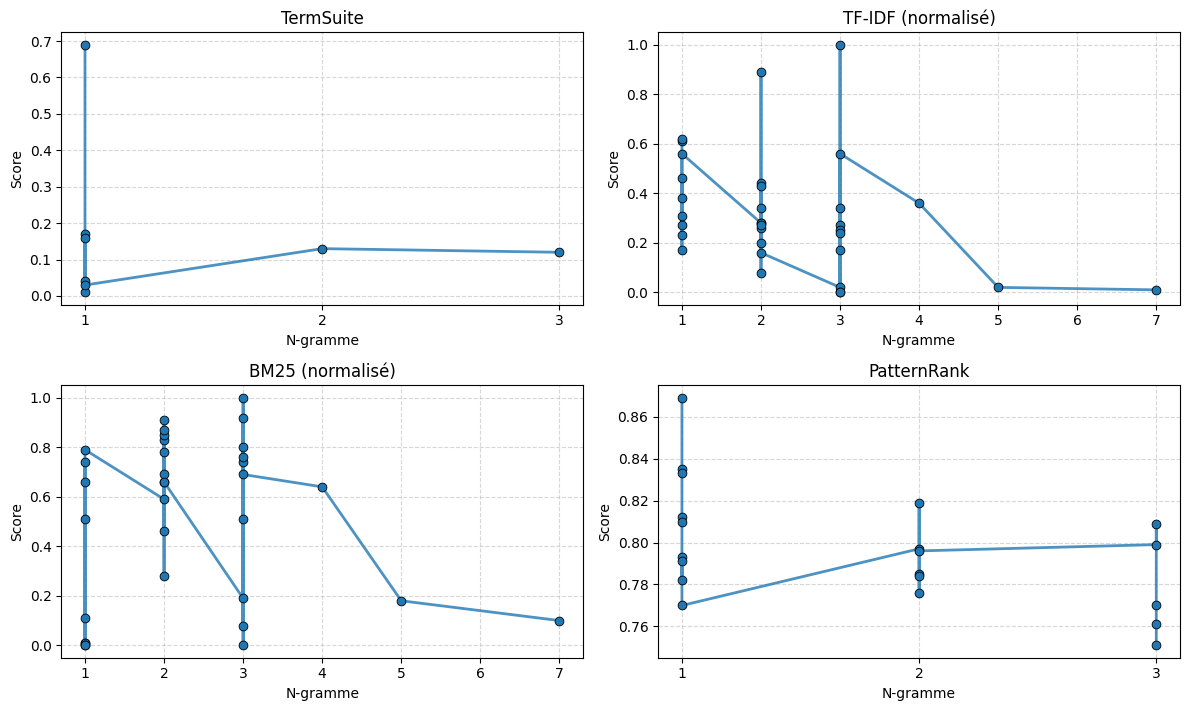

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- Load CSV ---
csv_path = "courbe_termes_scores_charcot.csv"
df = pd.read_csv(csv_path)

# --- Columns ---
x_col = "N-gramme"
score_cols = ["TermSuite", "Normalized_TF-IDF", "Normalized_BM25", "PatternRank"]

# --- Display labels (for plotting only) ---
display_labels = {
    "TermSuite": "TermSuite",
    "Normalized_TF-IDF": "TF-IDF (normalisé)",
    "Normalized_BM25": "BM25 (normalisé)",
    "PatternRank": "PatternRank"
}

# --- Convert to numeric ---
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
for c in score_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows where N-gramme is NA
df = df.dropna(subset=[x_col])

def plot_subplots_points_and_lines(df, score_cols, title, out_png=None):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, score_cols):
        # Keep only valid rows for this score
        d = df[[x_col, col]].dropna().sort_values(x_col)

        # --- Line (tracé) ---
        ax.plot(
            d[x_col],
            d[col],
            linewidth=2,
            alpha=0.8
        )

        # --- Points ---
        ax.scatter(
            d[x_col],
            d[col],
            s=40,
            edgecolor="black",
            linewidth=0.6,
            zorder=3
        )

        ax.set_title(display_labels[col])
        ax.set_xlabel("N-gramme")
        ax.set_ylabel("Score")
        ax.grid(True, linestyle="--", alpha=0.5)

        # N-gramme is discrete
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Hide unused axes if any
    for i in range(len(score_cols), len(axes)):
        axes[i].axis("off")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if out_png:
        fig.savefig(out_png, dpi=600)

    return fig

plot_subplots_points_and_lines(
    df,
    score_cols,
    title="",
    out_png="courbes_scores_subplots_points_lines_charcot.png",
)

plt.show()

# Autres -- graphiques individuels (tracé)

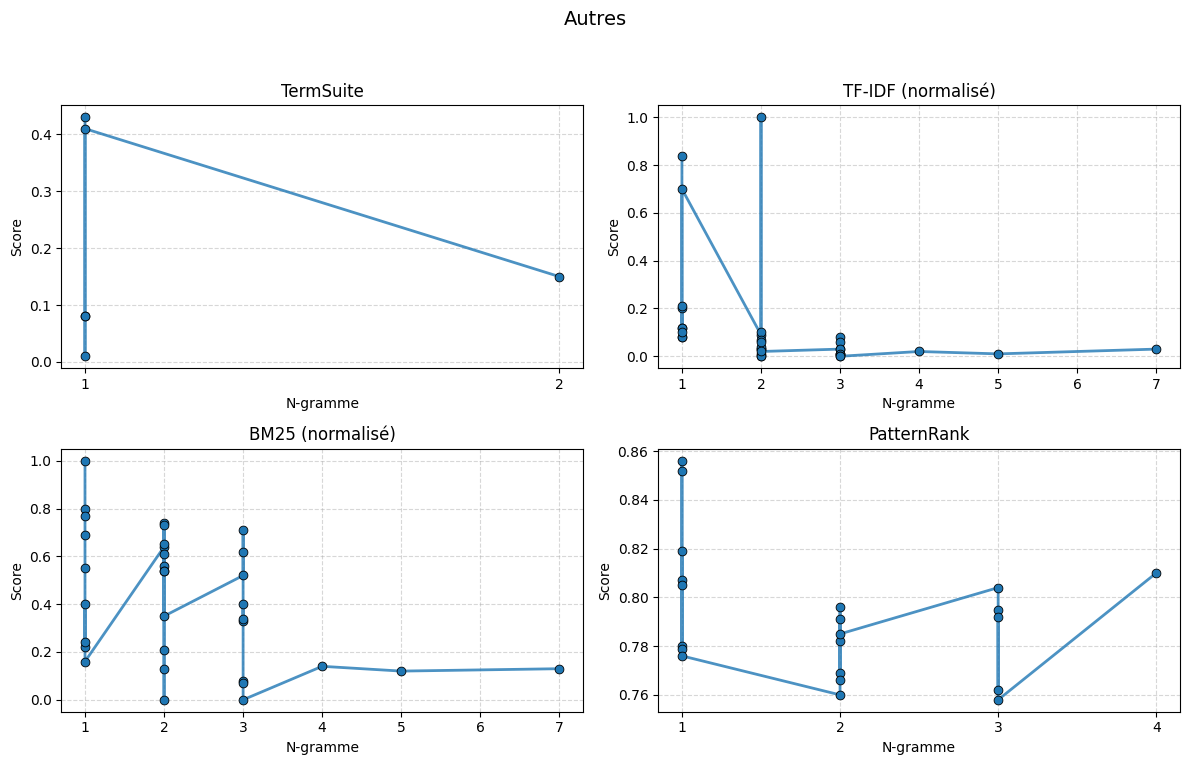

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- Load CSV ---
csv_path = "courbe_termes_scores_autres.csv"
df = pd.read_csv(csv_path)

# --- Columns ---
x_col = "N-gramme"
score_cols = ["TermSuite", "Normalized_TF-IDF", "Normalized_BM25", "PatternRank"]

# --- Display labels (for plotting only) ---
display_labels = {
    "TermSuite": "TermSuite",
    "Normalized_TF-IDF": "TF-IDF (normalisé)",
    "Normalized_BM25": "BM25 (normalisé)",
    "PatternRank": "PatternRank"
}

# --- Convert to numeric ---
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
for c in score_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows where N-gramme is NA
df = df.dropna(subset=[x_col])

def plot_subplots_points_and_lines(df, score_cols, title, out_png=None):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, score_cols):
        # Keep only valid rows for this score
        d = df[[x_col, col]].dropna().sort_values(x_col)

        # --- Line (tracé) ---
        ax.plot(
            d[x_col],
            d[col],
            linewidth=2,
            alpha=0.8
        )

        # --- Points ---
        ax.scatter(
            d[x_col],
            d[col],
            s=40,
            edgecolor="black",
            linewidth=0.6,
            zorder=3
        )

        ax.set_title(display_labels[col])
        ax.set_xlabel("N-gramme")
        ax.set_ylabel("Score")
        ax.grid(True, linestyle="--", alpha=0.5)

        # N-gramme is discrete
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Hide unused axes if any
    for i in range(len(score_cols), len(axes)):
        axes[i].axis("off")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if out_png:
        fig.savefig(out_png, dpi=600)

    return fig

plot_subplots_points_and_lines(
    df,
    score_cols,
    title="Autres",
    out_png="courbes_scores_subplots_points_lines_autres.png",
)

plt.show()


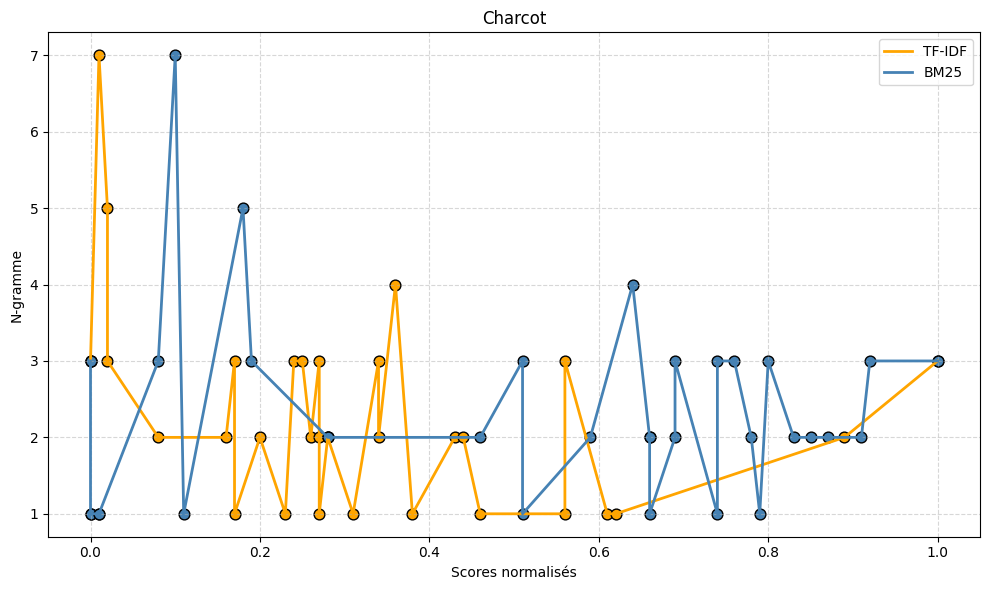

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("courbe_termes_scores_charcot.csv")

# Convert columns directly to float (no comma replacement)
df["Normalized_TF-IDF"] = df["Normalized_TF-IDF"].astype(float)
df["Normalized_BM25"] = df["Normalized_BM25"].astype(float)
df["N-gramme"] = df["N-gramme"].astype(float)   # or int, but float is okay for plotting

# Sort for cleaner lines
df_sorted_tfidf = df.sort_values("Normalized_TF-IDF")
df_sorted_bm25 = df.sort_values("Normalized_BM25")

plt.figure(figsize=(10,6))

# ---- TF-IDF: line + points ----
plt.plot(df_sorted_tfidf["Normalized_TF-IDF"], df_sorted_tfidf["N-gramme"],
         label="TF-IDF", linewidth=2, color="orange")

plt.scatter(df_sorted_tfidf["Normalized_TF-IDF"], df_sorted_tfidf["N-gramme"],
            color="orange", edgecolor="black", s=60)

# ---- BM25: line + points ----
plt.plot(df_sorted_bm25["Normalized_BM25"], df_sorted_bm25["N-gramme"],
         label="BM25", linewidth=2, color="steelblue")

plt.scatter(df_sorted_bm25["Normalized_BM25"], df_sorted_bm25["N-gramme"],
            color="steelblue", edgecolor="black", s=60)

# Labels and formatting
plt.xlabel("Scores normalisés")
plt.ylabel("N-gramme")
#plt.title("Nb_termes en fonction des scores normalisés (TF-IDF & BM25)")
plt.title("Charcot")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig('courbe_termes_scores_charcot.png', dpi=600)
plt.show()

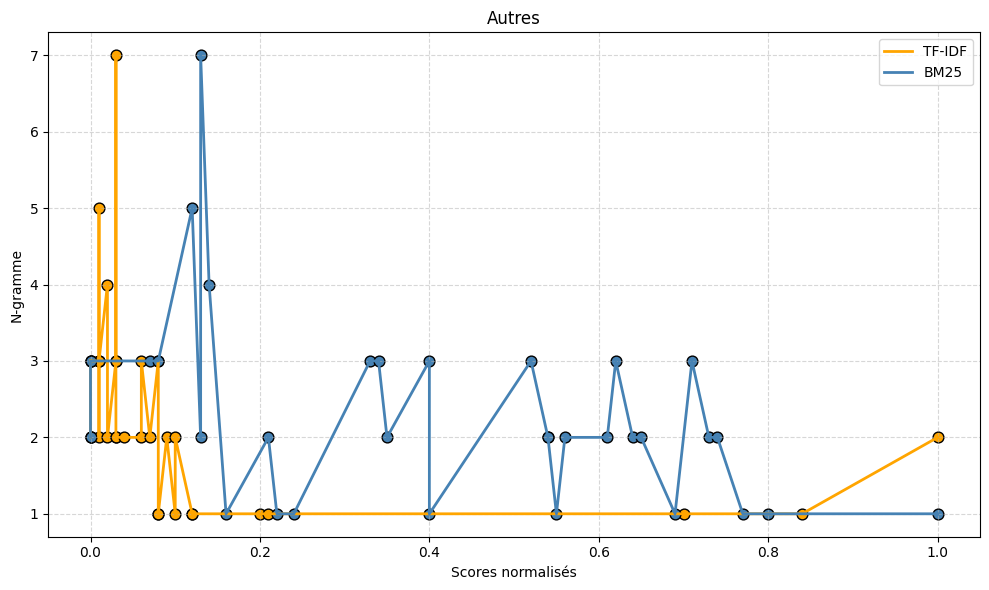

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("courbe_termes_scores_autres.csv")

# Convert columns directly to float (no comma replacement)
df["Normalized_TF-IDF"] = df["Normalized_TF-IDF"].astype(float)
df["Normalized_BM25"] = df["Normalized_BM25"].astype(float)
df["N-gramme"] = df["N-gramme"].astype(float)   # or int, but float is okay for plotting

# Sort for cleaner lines
df_sorted_tfidf = df.sort_values("Normalized_TF-IDF")
df_sorted_bm25 = df.sort_values("Normalized_BM25")

plt.figure(figsize=(10,6))

# ---- TF-IDF: line + points ----
plt.plot(df_sorted_tfidf["Normalized_TF-IDF"], df_sorted_tfidf["N-gramme"],
         label="TF-IDF", linewidth=2, color="orange")

plt.scatter(df_sorted_tfidf["Normalized_TF-IDF"], df_sorted_tfidf["N-gramme"],
            color="orange", edgecolor="black", s=60)

# ---- BM25: line + points ----
plt.plot(df_sorted_bm25["Normalized_BM25"], df_sorted_bm25["N-gramme"],
         label="BM25", linewidth=2, color="steelblue")

plt.scatter(df_sorted_bm25["Normalized_BM25"], df_sorted_bm25["N-gramme"],
            color="steelblue", edgecolor="black", s=60)

# Labels and formatting
plt.xlabel("Scores normalisés")
plt.ylabel("N-gramme")
#plt.title("Nb_termes en fonction des scores normalisés (TF-IDF & BM25)")
plt.title("Autres")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig('courbe_termes_scores_autres.png', dpi=600)
plt.show()